In [ ]:
!pip install sae-lens
!pip install transformers bitsandbytes accelerate datasets tqdm matplotlib seaborn statsmodels

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from sae_lens import SAE
from datasets import load_dataset
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, re
from collections import defaultdict
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from statsmodels.stats.contingency_tables import mcnemar

# --------------------
# Setup device
# --------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --------------------
# CONFIG: 2B base vs 2B-IT
# --------------------
MODEL_A_ID = "google/gemma-2-2b"        # Base model (student / target)
MODEL_B_ID = "google/gemma-2-2b-it"     # 2B-IT model (teacher / source)

STITCH_LAYER_A = 20   # Gemma 2B layer 20
STITCH_LAYER_B = 20   # Gemma 2B-IT layer 20 (same index)

SAE_A_RELEASE = "gemma-scope-2b-pt-res-canonical"
SAE_B_RELEASE = "gemma-scope-2b-pt-res-canonical"
SAE_A_ID = f"layer_{STITCH_LAYER_A}/width_16k/canonical"
SAE_B_ID = f"layer_{STITCH_LAYER_B}/width_16k/canonical"

DATASET_NAME = "NeelNanda/openwebtext-tokenized-9b"
CONTEXT_LENGTH = 128
BATCH_SIZE = 8         # Slightly smaller for functional KL training
NUM_EPOCHS = 1         # We cap by MAX_STITCH_TRAIN_STEPS instead
LEARNING_RATE = 1e-4
ACTIVATION_CACHE_SIZE = 10_000       # number of sequences to use for stitch training
NUM_SAMPLES_FOR_SVCCA = 200

# GSM8K config (base values)
GSM8K_FEATURE_SAMPLES = 100           # for feature *selection* via ablation
GSM8K_EVAL_SAMPLES = 100
NUM_TOP_FEATURES = 50                 # k = number of "reasoning features"

# REVISION(1): ablation-based feature selection
# Limit of top-M features (by |activation|) per sample that we actually ablate.
ABLATION_TOP_M_PER_SAMPLE = 32

# Smaller strengths – we’ll try mild nudges
GRAFTING_STRENGTHS = [0.0, 1e-2, 2e-2, 3e-2, 4e-2, 5e-2, 6e-2, 7e-2, 1e-1, 2e-1, 3e-1]
MAX_NEW_TOKENS = 400
EVAL_BATCH_SIZE = 8
CHECKPOINT_FILE = "grafting_checkpoint_2b_2bit.json"
EVALUATION_QUESTIONS_FILE = "gsm8k_eval_samples_2b_2bit.json"

# Target norm for teacher SAE features before stitching
TARGET_SAE_NORM = 10.0

# REVISION(2): functional stitch training via KL – limit steps instead of full epochs over huge corpus
MAX_STITCH_TRAIN_STEPS = 500

# --------------------
# Hugging Face login (replace token string or use hf-cli)
# --------------------
from huggingface_hub import login
login(token='XXX')  # <--- REPLACE WITH YOUR TOKEN OR USE CLI

# --------------------
# Load tokenizer and models
# --------------------
print("Loading tokenizer and models...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_A_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Loading {MODEL_A_ID} (base)...")
model_a = AutoModelForCausalLM.from_pretrained(
    MODEL_A_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)

print(f"Loading {MODEL_B_ID} (2B-IT)...")
model_b = AutoModelForCausalLM.from_pretrained(
    MODEL_B_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)

print("Models and tokenizer loaded successfully.")
print(f"Using fixed layer pair: 2B base Layer {STITCH_LAYER_A} ↔ 2B-IT Layer {STITCH_LAYER_B}")

# --------------------
# Helper functions
# --------------------
def get_unnormalized_activations(model, tokens, layer_idx, return_all_positions=False):
    with torch.no_grad():
        if hasattr(model, "model"):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)

        all_activations = outputs.hidden_states[layer_idx].to(torch.float32)

        if return_all_positions:
            b, seq, d = all_activations.shape
            return all_activations.view(-1, d).cpu()
        else:
            return all_activations[:, -1].cpu()

def get_normalized_activations(model, tokens, layer_idx, return_all_positions=False):
    with torch.no_grad():
        if hasattr(model, "model"):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)

        all_activations = outputs.hidden_states[layer_idx].to(torch.float32)

        if return_all_positions:
            b, seq, d = all_activations.shape
            reshaped = all_activations.view(-1, d)
            normalized = torch.nn.functional.layer_norm(reshaped, [d])
            return normalized.cpu()
        else:
            last_token_acts = all_activations[:, -1]
            normalized = torch.nn.functional.layer_norm(last_token_acts, [last_token_acts.shape[-1]])
            return normalized.cpu()

def get_sae_features(model, sae, tokens, layer_idx):
    """SAE features for last token"""
    with torch.no_grad():
        if hasattr(model, "model"):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
        activations = outputs.hidden_states[layer_idx].to(torch.float32)
        features = sae.encode(activations[:, -1])
        return features.cpu()

def centered_kernel_alignment(acts_a, acts_b, device):
    acts_a = acts_a.to(device)
    acts_b = acts_b.to(device)

    acts_a = acts_a - acts_a.mean(dim=0, keepdim=True)
    acts_b = acts_b - acts_b.mean(dim=0, keepdim=True)

    gram_a = torch.mm(acts_a, acts_a.T)
    gram_b = torch.mm(acts_b, acts_b.T)

    n = gram_a.shape[0]
    H = torch.eye(n, device=device) - torch.ones(n, n, device=device) / n
    gram_a_centered = H @ gram_a @ H
    gram_b_centered = H @ gram_b @ H

    numerator = torch.trace(gram_a_centered @ gram_b_centered)
    denominator = torch.sqrt(
        torch.trace(gram_a_centered @ gram_a_centered) *
        torch.trace(gram_b_centered @ gram_b_centered)
    )

    if denominator > 1e-8:
        cka_score = (numerator / denominator).item()
    else:
        cka_score = 0.0

    return abs(cka_score)

class EnhancedStitch(nn.Module):
    def __init__(self, dim_a, dim_b, dropout_rate=0.1):
        super().__init__()
        self.up = nn.Linear(dim_a, dim_b)
        self.down = nn.Linear(dim_b, dim_a)
        self.dropout = nn.Dropout(dropout_rate)

        nn.init.xavier_uniform_(self.up.weight)
        nn.init.xavier_uniform_(self.down.weight)
        nn.init.zeros_(self.up.bias)
        nn.init.zeros_(self.down.bias)

    def forward_up(self, x, use_dropout=True):   # A -> B
        x = self.up(x)
        if use_dropout and self.training:
            x = self.dropout(x)
        return x

    def forward_down(self, x, use_dropout=True): # B -> A
        x = self.down(x)
        if use_dropout and self.training:
            x = self.dropout(x)
        return x

class ActivationDataset(Dataset):
    # NOTE: retained for compatibility, but *not* used as the main objective anymore.
    # REVISION(2): Stitch is now trained via functional KL on logits, not just L2 in SAE space.
    def __init__(self, acts_a_tensor, acts_b_tensor):
        self.acts_a = acts_a_tensor
        self.acts_b = acts_b_tensor

    def __len__(self):
        return self.acts_a.shape[0]

    def __getitem__(self, idx):
        return self.acts_a[idx], self.acts_b[idx]

# --------------------
# Load SAEs
# --------------------
print("Loading Gemma Scope SAEs for evaluation...")
try:
    print(f"Loading SAE A (base): {SAE_A_RELEASE}/{SAE_A_ID}")
    sae_a: SAE = SAE.from_pretrained(
        release=SAE_A_RELEASE, sae_id=SAE_A_ID, device=device
    )

    print(f"Loading SAE B (2B-IT): {SAE_B_RELEASE}/{SAE_B_ID}")
    sae_b: SAE = SAE.from_pretrained(
        release=SAE_B_RELEASE, sae_id=SAE_B_ID, device=device
    )

    print("SAEs loaded successfully!")
    print(f"SAE A (Layer {STITCH_LAYER_A}): d_in={sae_a.cfg.d_in}, d_sae={sae_a.cfg.d_sae}")
    print(f"SAE B (Layer {STITCH_LAYER_B}): d_in={sae_b.cfg.d_in}, d_sae={sae_b.cfg.d_sae}")
except Exception as e:
    print(f"Warning: Could not load SAEs - {e}")
    sae_a, sae_b = None, None
    raise RuntimeError("SAEs are required for this experiment")

# ================================
# 1. CKA VERIFICATION (ACTIVATION SPACE)
# ================================
print(f"\nUsing fixed layer pair: 2B base Layer {STITCH_LAYER_A} ↔ 2B-IT Layer {STITCH_LAYER_B}")
print("Verifying layer pair with CKA similarity...")
print("Preparing small dataset for verification...")

verification_dataset = load_dataset(
    DATASET_NAME, split="train", streaming=True
).take(NUM_SAMPLES_FOR_SVCCA)

tokens_list = []
for item in verification_dataset:
    tokens = torch.tensor(item["tokens"])[:CONTEXT_LENGTH]
    if len(tokens) < CONTEXT_LENGTH:
        tokens = torch.cat(
            [tokens, torch.full((CONTEXT_LENGTH - len(tokens),), tokenizer.pad_token_id)]
        )
    tokens_list.append(tokens.to(device))

all_acts_a, all_acts_b = [], []
for tokens in tqdm(tokens_list[:50], desc="Computing verification activations"):
    try:
        acts_a = get_normalized_activations(
            model_a, tokens.unsqueeze(0), STITCH_LAYER_A, return_all_positions=True
        )
        acts_b = get_normalized_activations(
            model_b, tokens.unsqueeze(0), STITCH_LAYER_B, return_all_positions=True
        )
        all_acts_a.append(acts_a)
        all_acts_b.append(acts_b)
    except Exception as e:
        print(f"Error in verification: {e}")
        continue

if len(all_acts_a) > 0:
    acts_a_stacked = torch.cat(all_acts_a, dim=0)
    acts_b_stacked = torch.cat(all_acts_b, dim=0)
    print(
        f"Verification using {acts_a_stacked.shape[0]} total positions "
        f"from {len(all_acts_a)} sequences"
    )

    cka_score = centered_kernel_alignment(acts_a_stacked, acts_b_stacked, device)
    print(
        f"CKA similarity between 2B base Layer {STITCH_LAYER_A} "
        f"and 2B-IT Layer {STITCH_LAYER_B}: {cka_score:.4f}"
    )
else:
    print("Could not compute verification - proceeding anyway")

# ================================
# 2. STITCH INITIALIZATION (SAE SPACE)
# ================================
dim_a = sae_a.cfg.d_sae   # e.g. 16384
dim_b = sae_b.cfg.d_sae   # e.g. 16384

stitch_model = EnhancedStitch(dim_a, dim_b, dropout_rate=0.1).to(device)

# REVISION(2): functional objective; we freeze Teacher/Student/SAEs and only train stitch_model
optimizer = torch.optim.AdamW(stitch_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

for p in model_a.parameters():
    p.requires_grad_(False)
for p in model_b.parameters():
    p.requires_grad_(False)
for p in sae_a.parameters():
    p.requires_grad_(False)
for p in sae_b.parameters():
    p.requires_grad_(False)

model_a.eval()
model_b.eval()
sae_a.eval()
sae_b.eval()

print(f"\nEnhanced Stitch Architecture (SAE space): {dim_a} -> {dim_b}")
print("Training objective: KL(Teacher logits || Student+Stitch logits) [REVISION(2)]")
print(f"Using up to {MAX_STITCH_TRAIN_STEPS} training steps from OpenWebText")




Using device: cuda
Loading tokenizer and models...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

...

Loading SAE B (2B-IT): gemma-scope-2b-pt-res-canonical/layer_20/width_16k/canonical
SAEs loaded successfully!
SAE A (Layer 20): d_in=2304, d_sae=16384
SAE B (Layer 20): d_in=2304, d_sae=16384

Using fixed layer pair: 2B base Layer 20 ↔ 2B-IT Layer 20
Verifying layer pair with CKA similarity...
Preparing small dataset for verification...


README.md:   0%|          | 0.00/386 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/37 [00:00<?, ?it/s]

Computing verification activations:   0%|          | 0/50 [00:00<?, ?it/s]

Verification using 6400 total positions from 50 sequences
CKA similarity between 2B base Layer 20 and 2B-IT Layer 20: 0.6822

Enhanced Stitch Architecture (SAE space): 16384 -> 16384
Training objective: KL(Teacher logits || Student+Stitch logits) [REVISION(2)]
Using up to 500 training steps from OpenWebText



Starting stitch training in SAE space (MSE)...


Resolving data files:   0%|          | 0/37 [00:00<?, ?it/s]

Step 50/500 - MSE loss: 0.5622
Step 100/500 - MSE loss: 0.4852
Step 150/500 - MSE loss: 0.5423
Step 200/500 - MSE loss: 0.3968
Step 250/500 - MSE loss: 0.4483
Step 300/500 - MSE loss: 0.3961
Step 350/500 - MSE loss: 0.3921
Step 400/500 - MSE loss: 0.3858
Step 450/500 - MSE loss: 0.3622
Step 500/500 - MSE loss: 0.3603
Stitch training in SAE space complete!


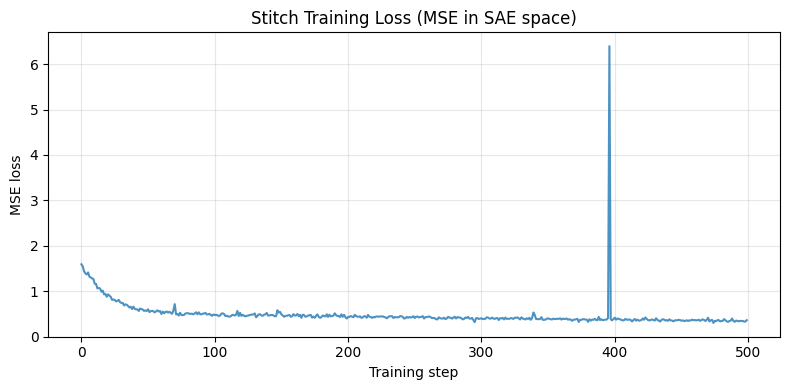

In [2]:
# --------------------
# SIMPLE STITCH TRAINING IN SAE SPACE (MSE OBJECTIVE)
# --------------------
# Instead of training via KL with a forward hook, we directly train the stitch
# to map student SAE features -> teacher SAE features on OpenWebText.
#
# This is much more stable and avoids any autograd issues with hooks.

grafting_context = {}  # we'll still use this later for evaluation hooks


def make_train_stream():
    # We use streaming dataset to avoid loading everything into RAM
    return load_dataset(DATASET_NAME, split="train", streaming=True).take(ACTIVATION_CACHE_SIZE)


def mse_stitch_train_step(batch_items):
    """
    One training step on a small batch of OpenWebText tokens.
    Objective: minimize MSE between:
        f_B       = SAE-B(teacher layer hidden)
        f_B_hat   = stitch( SAE-A(student layer hidden) )
    """
    # -------------------------
    # Build tensor batch
    # -------------------------
    batch_tokens = []
    for item in batch_items:
        tokens = torch.tensor(item["tokens"])[:CONTEXT_LENGTH]
        if len(tokens) < CONTEXT_LENGTH:
            tokens = torch.cat(
                [tokens, torch.full((CONTEXT_LENGTH - len(tokens),), tokenizer.pad_token_id)]
            )
        batch_tokens.append(tokens)

    input_ids = torch.stack(batch_tokens, dim=0).to(device)  # [B, T]
    attention_mask = (input_ids != tokenizer.pad_token_id).long().to(device)

    # -------------------------
    # Teacher hidden + SAE-B (no grad)
    # -------------------------
    with torch.no_grad():
        teacher_outputs = model_b.model(
            input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )
        teacher_hidden = teacher_outputs.hidden_states[STITCH_LAYER_B]  # [B, T, D_model]

        attn = attention_mask.unsqueeze(-1)  # [B, T, 1]
        masked = teacher_hidden * attn
        lengths = attn.squeeze(-1).sum(dim=1, keepdim=True).clamp(min=1.0)  # [B, 1]
        avg_teacher = masked.sum(dim=1) / lengths                             # [B, D_model]

        f_B = sae_b.encode(avg_teacher.to(torch.float32))                     # [B, d_sae_B]
        f_B = f_B.detach()                                                    # constant target

    # -------------------------
    # Student hidden + SAE-A (we allow grad through stitch_model)
    # -------------------------
    with torch.no_grad():
        student_outputs = model_a.model(
            input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )
        student_hidden = student_outputs.hidden_states[STITCH_LAYER_A]        # [B, T, D_model]

        masked_s = student_hidden * attn
        avg_student = masked_s.sum(dim=1) / lengths                           # [B, D_model]

    # We don't need grads through SAE-A params, but we DO want stitch_model grads.
    # That's fine: f_A can be treated as a constant input to a Linear layer.
    f_A = sae_a.encode(avg_student.to(torch.float32))                         # [B, d_sae_A]

    # -------------------------
    # Stitch and MSE loss
    # -------------------------
    f_B_hat = stitch_model.forward_up(f_A, use_dropout=False)                 # [B, d_sae_B]

    loss = F.mse_loss(f_B_hat, f_B)
    return loss


print("\nStarting stitch training in SAE space (MSE)...")
loss_history = []
step = 0
epoch = 0

stitch_model.train()

while step < MAX_STITCH_TRAIN_STEPS:
    epoch += 1
    train_stream = make_train_stream()
    batch_items = []

    for item in train_stream:
        batch_items.append(item)
        if len(batch_items) == BATCH_SIZE:
            optimizer.zero_grad()
            loss = mse_stitch_train_step(batch_items)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(stitch_model.parameters(), max_norm=1.0)
            optimizer.step()

            loss_history.append(loss.item())
            step += 1
            batch_items = []

            if step % 50 == 0:
                print(f"Step {step}/{MAX_STITCH_TRAIN_STEPS} - MSE loss: {loss.item():.4f}")

            if step >= MAX_STITCH_TRAIN_STEPS:
                break

    scheduler.step()

stitch_model.eval()
print("Stitch training in SAE space complete!")

plt.figure(figsize=(8, 4))
plt.plot(loss_history, alpha=0.8)
plt.title("Stitch Training Loss (MSE in SAE space)")
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"stitch_training_MSE_SAE_2B-2B-IT_L{STITCH_LAYER_A}.png", dpi=150, bbox_inches="tight")
plt.show()


In [3]:
GSM8K_EVAL_SAMPLES = 300

In [4]:

# ================================
# 3. SAE-SPACE EVALUATION (OpenWebText)
# ================================
# NOTE: This is left mostly unchanged for diagnostic purposes,
# still comparing feature transfer MSE vs random projection.
print("\nEvaluating stitch quality in SAE space on held-out samples...")

test_samples = []
test_dataset = (
    load_dataset(DATASET_NAME, split="train", streaming=True)
    .skip(ACTIVATION_CACHE_SIZE // 4)
    .take(10)
)

for item in test_dataset:
    test_tokens = torch.tensor(item["tokens"])[:CONTEXT_LENGTH]
    if len(test_tokens) < CONTEXT_LENGTH:
        test_tokens = torch.cat(
            [test_tokens, torch.full((CONTEXT_LENGTH - len(test_tokens),), tokenizer.pad_token_id)]
        )
    test_samples.append(test_tokens.to(device).unsqueeze(0))

all_transfer_losses = []
all_random_losses = []
all_reverse_losses = []
all_feature_preservation_scores = []

stitch_model.eval()
model_a.eval()
model_b.eval()
sae_a.eval()
sae_b.eval()

for i, test_tokens in enumerate(test_samples):
    print(f"\nTest Sample {i+1}")
    try:
        with torch.no_grad():
            if hasattr(model_a, "model"):
                outputs_a = model_a.model(test_tokens, output_hidden_states=True)
            else:
                outputs_a = model_a(test_tokens, output_hidden_states=True)
            acts_a = outputs_a.hidden_states[STITCH_LAYER_A]

            if hasattr(model_b, "model"):
                outputs_b = model_b.model(test_tokens, output_hidden_states=True)
            else:
                outputs_b = model_b(test_tokens, output_hidden_states=True)
            acts_b = outputs_b.hidden_states[STITCH_LAYER_B]

            features_a_all = sae_a.encode(acts_a.squeeze(0))
            features_b_all = sae_b.encode(acts_b.squeeze(0))

    except Exception as e:
        print(f"Error: {e}")
        continue

    seq_len = features_a_all.shape[0]
    eval_positions = [0, seq_len // 2, seq_len - 1] if seq_len > 1 else [0]

    position_metrics = {
        "transfer": [],
        "reverse": [],
        "random": [],
        "feature_preservation": [],
    }

    dim_a = sae_a.cfg.d_sae
    dim_b = sae_b.cfg.d_sae
    random_projection = nn.Linear(dim_b, dim_a).to(device)

    for pos_idx in eval_positions:
        f_a = features_a_all[pos_idx].to(device)
        f_b = features_b_all[pos_idx].to(device)

        with torch.no_grad():
            f_a_to_b = stitch_model.forward_up(f_a, use_dropout=False)   # base->IT
            transfer_loss = F.mse_loss(f_a_to_b, f_b).item()

            f_b_to_a = stitch_model.forward_down(f_b, use_dropout=False) # IT->base
            reverse_loss = F.mse_loss(f_b_to_a, f_a).item()

            f_b_random = random_projection(f_b)
            random_loss = F.mse_loss(f_b_random, f_a).item()

            active_b = (torch.abs(f_b) > 0.1).float()
            active_transferred = (torch.abs(f_b_to_a) > 0.1).float()
            preserved = (active_b * active_transferred).sum()
            total_active_b = active_b.sum()
            preservation_rate = (preserved / total_active_b).item() if total_active_b > 0 else 0.0

            position_metrics["transfer"].append(transfer_loss)
            position_metrics["reverse"].append(reverse_loss)
            position_metrics["random"].append(random_loss)
            position_metrics["feature_preservation"].append(preservation_rate)

    avg_transfer = np.mean(position_metrics["transfer"])
    avg_reverse = np.mean(position_metrics["reverse"])
    avg_random = np.mean(position_metrics["random"])
    avg_preservation = np.mean(position_metrics["feature_preservation"])

    all_transfer_losses.append(avg_transfer)
    all_reverse_losses.append(avg_reverse)
    all_random_losses.append(avg_random)
    all_feature_preservation_scores.append(avg_preservation)

    print(f"  Base->IT Transfer MSE: {avg_transfer:.4f}")
    print(f"  IT->Base Transfer MSE: {avg_reverse:.4f} ← Grafting direction")
    print(f"  Random Baseline MSE:   {avg_random:.4f}")
    print(f"  Feature Preservation:  {avg_preservation:.2%}")

print("\n" + "="*60)
print("FINAL RESULTS (SAE Feature Space Transfer: 2B base ↔ 2B-IT)")
print("="*60)
print(f"Average Base->IT Transfer MSE:   {np.mean(all_transfer_losses):.4f}")
print(f"Average IT->Base Transfer MSE:   {np.mean(all_reverse_losses):.4f}")
print(f"Average Random Baseline MSE:     {np.mean(all_random_losses):.4f}")
print(f"Average Feature Preservation:    {np.mean(all_feature_preservation_scores):.2%}")
print("-" * 60)

up_improvement = np.mean(all_random_losses) / np.mean(all_transfer_losses)
down_improvement = np.mean(all_random_losses) / np.mean(all_reverse_losses)
print(f"Base->IT Improvement:            {up_improvement:.2f}x over random")
print(f"IT->Base Improvement:            {down_improvement:.2f}x over random")
print("="*60)

# ================================
# 4. GSM8K REASONING + DYNAMIC GRAFTING
# ================================

def extract_numerical_answer(text):
    text = text.replace(",", "")
    patterns = [
        r"####\s*([+-]?\d+(?:\.\d+)?)",
        r"[Tt]he answer is\s*([+-]?\d+(?:\.\d+)?)",
        r"[Aa]nswer:\s*([+-]?\d+(?:\.\d+)?)",
        r"=\s*([+-]?\d+(?:\.\d+)?)(?:\s|$)",
        r"\$([+-]?\d+(?:\.\d+)?)",
        r"\\boxed\{(-?\d+(\.\d+)?)\}",
    ]
    for pattern in patterns:
        matches = re.findall(pattern, text)
        if matches:
            match = matches[-1]
            try:
                return float(match[0] if isinstance(match, tuple) else match)
            except (ValueError, IndexError):
                continue
    numbers = re.findall(r"([+-]?\d+(?:\.\d+)?)", text[-100:])
    if numbers:
        try:
            return float(numbers[-1])
        except ValueError:
            pass
    return None

# --------------------
# REVISION(1): ABLATION-BASED FEATURE SELECTION
# --------------------
ablation_context = {}

def teacher_ablation_hook(module, args, output):
    """
    REVISION(1): Hook used ONLY during feature selection to *zero-ablate* a single SAE feature.
    The procedure:
    - Take the average hidden state at STITCH_LAYER_B.
    - Encode with SAE-B -> SAE feature vector.
    - Zero out the selected feature index.
    - Decode back to residual space.
    - Adjust all token positions by the delta between ablated and original average.
    This approximates "zeroing" that feature's contribution to downstream logits.
    """
    feature_id = ablation_context.get("feature_id", None)
    if feature_id is None:
        return output

    hidden = output[0] if isinstance(output, tuple) else output  # [B, T, D]
    with torch.no_grad():
        B, T, D = hidden.shape
        avg_act = hidden.mean(dim=1)  # [B, D]
        features = sae_b.encode(avg_act.to(torch.float32))  # [B, d_sae]
        features_ablated = features.clone()
        features_ablated[:, feature_id] = 0.0
        decoded_ablated = sae_b.decode(features_ablated.to(next(sae_b.parameters()).dtype))  # [B, D]
        delta = (decoded_ablated - avg_act).unsqueeze(1)  # [B, 1, D]
        hidden_ablated = hidden + delta.to(hidden.dtype)
    if isinstance(output, tuple):
        return (hidden_ablated,) + output[1:]
    else:
        return hidden_ablated



Evaluating stitch quality in SAE space on held-out samples...


Resolving data files:   0%|          | 0/37 [00:00<?, ?it/s]


Test Sample 1
  Base->IT Transfer MSE: 1.2073
  IT->Base Transfer MSE: 2.4576 ← Grafting direction
  Random Baseline MSE:   1.7775
  Feature Preservation:  95.24%

Test Sample 2
  Base->IT Transfer MSE: 1.0230
  IT->Base Transfer MSE: 2.4528 ← Grafting direction
  Random Baseline MSE:   1.8231
  Feature Preservation:  89.29%

Test Sample 3
  Base->IT Transfer MSE: 1.1261
  IT->Base Transfer MSE: 2.2698 ← Grafting direction
  Random Baseline MSE:   1.6166
  Feature Preservation:  89.69%

Test Sample 4
  Base->IT Transfer MSE: 1.2538
  IT->Base Transfer MSE: 2.5158 ← Grafting direction
  Random Baseline MSE:   1.8244
  Feature Preservation:  93.68%

Test Sample 5
  Base->IT Transfer MSE: 1.3381
  IT->Base Transfer MSE: 2.6350 ← Grafting direction
  Random Baseline MSE:   1.8436
  Feature Preservation:  91.58%

Test Sample 6
  Base->IT Transfer MSE: 1.2788
  IT->Base Transfer MSE: 2.8269 ← Grafting direction
  Random Baseline MSE:   2.1339
  Feature Preservation:  93.05%

Test Sample 7
 

In [5]:
def compute_teacher_answer_logprob(question, answer_text):
    """
    Helper: compute sum log p_teacher(answer_tokens | prompt).
    Used as the 'correct-answer logit' in ablation impact.

    Fixed version: always calls model_b (CausalLM) so we get logits,
    but hooks on model_b.model.layers[...] still fire.
    """
    prompt = f"Question: {question}\nLet me solve this step by step:"
    target = f" The answer is {answer_text}"

    # Tokenize
    prompt_ids = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).input_ids.to(device)

    full_ids = tokenizer(
        prompt + target,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).input_ids.to(device)

    # Identify which positions correspond to answer tokens
    prompt_len = prompt_ids.shape[1]
    full_len = full_ids.shape[1]

    # Autoregressive: token at index i is predicted from logits at i-1
    input_ids = full_ids[:, :-1].clone()
    labels = full_ids[:, 1:].clone()          # shift by 1
    answer_mask = torch.zeros_like(labels)
    # positions predicting answer tokens
    answer_mask[:, prompt_len-1:full_len-1] = 1

    attention_mask = (input_ids != tokenizer.pad_token_id).long().to(device)

    with torch.no_grad():
        # IMPORTANT: call model_b (CausalLM), not model_b.model
        outputs = model_b(
            input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True,
        )

        # Robustly get logits
        if hasattr(outputs, "logits") and outputs.logits is not None:
            logits = outputs.logits  # [1, T-1, V]
        else:
            # Fallback: reconstruct logits from final hidden state via lm_head
            if hasattr(outputs, "last_hidden_state") and outputs.last_hidden_state is not None:
                hidden_for_logits = outputs.last_hidden_state
            else:
                hidden_for_logits = outputs.hidden_states[-1]
            logits = model_b.lm_head(hidden_for_logits)

    # Log probs over vocab
    log_probs = F.log_softmax(logits.float(), dim=-1)          # [1, T-1, V]

    # Gather log probs of correct tokens
    correct_token_log_probs = log_probs.gather(
        dim=-1, index=labels.unsqueeze(-1)
    ).squeeze(-1)                                             # [1, T-1]

    # Mask to only answer tokens
    masked_log_probs = correct_token_log_probs * answer_mask
    total_logprob = masked_log_probs.sum().item()
    return total_logprob


In [6]:

def compute_teacher_sae_for_question(question):
    """
    Helper to compute encoded SAE-B features (averaged across tokens) for a single question prompt.
    """
    prompt = f"Question: {question}\nLet me solve this step by step:"
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    with torch.no_grad():
        if hasattr(model_b, "model"):
            outputs = model_b.model(
                input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
            )
        else:
            outputs = model_b(
                input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
            )
        hidden = outputs.hidden_states[STITCH_LAYER_B]  # [1, T, D]
        attn = attention_mask.unsqueeze(-1)             # [1, T, 1]
        masked = hidden * attn
        lengths = attn.squeeze(-1).sum(dim=1, keepdim=True)
        lengths = torch.clamp(lengths, min=1.0)
        avg_act = masked.sum(dim=1) / lengths          # [1, D]
        features = sae_b.encode(avg_act.to(torch.float32)).squeeze(0).cpu()
    return features  # [d_sae_B]

def identify_reasoning_features_ablation(model_teacher, sae_teacher, tokenizer, gsm8k_samples, layer_idx):
    """
    REVISION(1): ablation-based feature selection.
    - For each GSM8K sample:
      * Compute teacher answer log-prob.
      * Compute Teacher SAE-B features at the graft layer.
      * Pick top-M dims by |activation| for this sample.
      * For each of those dims, run a *zero-ablation* forward via teacher_ablation_hook
        and recompute the answer log-prob.
      * Record the drop (base - ablated) as contribution to that feature's importance.
    - Final "score" for each feature is the average log-prob drop across samples in which it was ablated.
    - Select top-k features by this causal score.
    """
    print(f"Identifying reasoning features via ablation impact on Teacher's correct-answer logit...")
    feature_impacts = defaultdict(list)

    # Attach ablation hook to Teacher's graft layer
    teacher_layer = model_teacher.model.layers[layer_idx]
    ablation_handle = teacher_layer.register_forward_hook(teacher_ablation_hook)

    for i, sample in enumerate(tqdm(gsm8k_samples, desc="Ablation feature selection")):
        question = sample["question"]
        gold_num = extract_numerical_answer(sample["answer"])
        if gold_num is None:
            continue
        answer_text = str(int(gold_num) if float(gold_num).is_integer() else gold_num)

        try:
            # Base log-prob with no ablation
            ablation_context["feature_id"] = None
            base_logprob = compute_teacher_answer_logprob(question, answer_text)

            # SAE features for this question
            sae_vec = compute_teacher_sae_for_question(question)  # [d_sae]
            magnitudes = torch.abs(sae_vec)
            top_indices = torch.topk(magnitudes, ABLATION_TOP_M_PER_SAMPLE).indices.tolist()

            for fid in top_indices:
                ablation_context["feature_id"] = int(fid)
                ablated_logprob = compute_teacher_answer_logprob(question, answer_text)
                drop = base_logprob - ablated_logprob  # positive = feature helps correct answer
                feature_impacts[fid].append(drop)

        except Exception as e:
            print(f"Error in ablation for sample {i}: {e}")
            continue

    # Clean up hook
    ablation_context["feature_id"] = None
    ablation_handle.remove()

    feature_scores = {}
    for fid, drops in feature_impacts.items():
        if drops:
            avg_drop = float(np.mean(drops))
            freq = len(drops)
            feature_scores[fid] = {
                "score": avg_drop,
                "frequency": freq,
            }

    top_features = sorted(
        feature_scores.keys(), key=lambda x: feature_scores[x]["score"], reverse=True
    )[:NUM_TOP_FEATURES]

    print("\nTop 10 reasoning features by ablation impact:")
    for i, fid in enumerate(top_features[:10]):
        info = feature_scores[fid]
        print(
            f"  Feature {fid}: score={info['score']:.3f}, freq={info['frequency']}/{len(gsm8k_samples)}"
        )

    return top_features, feature_scores

# --------------------
# OFFLINE ADDITIVE GRAFTING HOOK (for evaluation)
# --------------------
def offline_grafting_hook(module, args, output):
    """
    Forward hook on Gemma 2B base model at STITCH_LAYER_A.

    Uses *dynamic* teacher SAE features per batch, stored in
    grafting_context["teacher_features"] by evaluate_gsm8k.

    Grafting is applied ONLY on the last token at this layer.

    REVISION(3): we now use pure additive interventions:
        r_student' = r_student + alpha * g
    instead of convex combinations (1-alpha)*r + alpha*g.
    """
    original_activation = output[0] if isinstance(output, tuple) else output  # [B, T, D] or [B, 1, D]
    strength = grafting_context.get("strength", 0.0)

    teacher_sae_batch = grafting_context.get("teacher_features", None)
    if strength == 0.0 or teacher_sae_batch is None:
        return output

    with torch.no_grad():
        device_local = original_activation.device

        teacher_sae = teacher_sae_batch.to(device_local)  # [B, d_sae_B]

        # Dtypes
        stitch_weight_dtype = stitch_model.down.weight.dtype   # typically float32
        sae_a_dtype = next(sae_a.parameters()).dtype           # typically float32
        resid_dtype = original_activation.dtype                # bfloat16

        # 1) Ensure teacher_sae uses stitch dtype
        f_B = teacher_sae.to(dtype=stitch_weight_dtype)

        # 2) IT -> base in SAE space (B -> A)
        f_A = stitch_model.forward_down(f_B, use_dropout=False)  # [B, d_sae_A], float32

        # 3) Decode into base residual space via SAE-A
        h_A_unnorm = sae_a.decode(f_A.to(dtype=sae_a_dtype))     # [B, D_model], float32

        # 4) LayerNorm in sae_a dtype, then cast to residual dtype
        h_A_norm = F.layer_norm(h_A_unnorm, [h_A_unnorm.shape[-1]])  # [B, D_model]
        h_A_norm = h_A_norm.to(dtype=resid_dtype, device=device_local)

        # 5) Mix ONLY on last token – ADDITIVE (not convex)
        B, T, D = original_activation.shape
        modified_activation = original_activation.clone()

        last_orig = original_activation[:, -1, :]          # [B, D]
        # REVISION(3): additive grafting
        last_grafted = last_orig + strength * h_A_norm
        modified_activation[:, -1, :] = last_grafted

    if isinstance(output, tuple):
        return (modified_activation,) + output[1:]
    else:
        return modified_activation

def evaluate_gsm8k(model, tokenizer, samples, strength=0.0):
    """
    Evaluate GSM8K with dynamic teacher-based grafting.

    For each batch:
      1) Run teacher model (2B-IT) on the *same prompts*.
      2) Get average hidden states at STITCH_LAYER_B.
      3) Encode with SAE-B -> teacher_sae [B, d_sae_B].
      4) Mask to selected feature ids (reasoning or random).
      5) L2-normalize to TARGET_SAE_NORM.
      6) Store in grafting_context["teacher_features"].
      7) Run base model with additive grafting hook active.

    REVISION(3): The hook itself uses r + alpha * g, not convex interpolation.
    """
    correct, total = 0, 0
    hook_handle = target_layer.register_forward_hook(offline_grafting_hook)
    print(f"\nEvaluating on GSM8K with grafting strength: {strength}")

    model_b.eval()
    sae_b.eval()

    feature_ids_tensor = None
    if grafting_context.get("reasoning_features_dict", None):
        feature_ids = list(grafting_context["reasoning_features_dict"].keys())
        feature_ids_tensor = torch.tensor(feature_ids, dtype=torch.long, device=device)

    for i in tqdm(range(0, len(samples), EVAL_BATCH_SIZE), desc=f"Strength {strength}"):
        batch_samples = samples[i : i + EVAL_BATCH_SIZE]
        prompts = [
            f"Question: {s['question']}\nLet me solve this step by step:" for s in batch_samples
        ]
        correct_answers = [extract_numerical_answer(s["answer"]) for s in batch_samples]
        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(device)

        # -----------------------------
        # Compute dynamic teacher SAE features per batch
        # -----------------------------
        with torch.no_grad():
            if hasattr(model_b, "model"):
                outputs_teacher = model_b.model(
                    inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    output_hidden_states=True,
                )
            else:
                outputs_teacher = model_b(
                    inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    output_hidden_states=True,
                )

            teacher_hidden = outputs_teacher.hidden_states[STITCH_LAYER_B]  # [B, T, D_model]
            attn = inputs["attention_mask"].unsqueeze(-1)                   # [B, T, 1]
            masked = teacher_hidden * attn
            lengths = attn.squeeze(-1).sum(dim=1, keepdim=True)             # [B, 1]
            lengths = torch.clamp(lengths, min=1.0)
            avg_act = masked.sum(dim=1) / lengths                           # [B, D_model]

            # SAE-B encode
            teacher_sae = sae_b.encode(avg_act.to(torch.float32))           # [B, d_sae_B]
            teacher_sae = teacher_sae.to(torch.float32)

            # Keep only selected feature dims (mask others to zero)
            if feature_ids_tensor is not None:
                mask = torch.zeros_like(teacher_sae)
                mask[:, feature_ids_tensor] = 1.0
                teacher_sae = teacher_sae * mask

            # Normalize to TARGET_SAE_NORM to avoid huge grafts
            norms = teacher_sae.norm(dim=-1, keepdim=True)                  # [B, 1]
            target = TARGET_SAE_NORM
            teacher_sae = torch.where(
                norms > 0,
                teacher_sae / norms * target,
                teacher_sae,
            )

        # Store for hook
        grafting_context["teacher_features"] = teacher_sae
        grafting_context["strength"] = strength

        # One-time debug if you want:
        if grafting_context.get("debug_once", True):
            print(
                "[grafting] teacher_sae norm (mean):",
                norms.mean().item(),
            )
            grafting_context["debug_once"] = False

        # -----------------------------
        # Run base model with graft
        # -----------------------------
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        responses = tokenizer.batch_decode(
            generated_ids[:, inputs["input_ids"].shape[1] :], skip_special_tokens=True
        )

        for j, response in enumerate(responses):
            predicted_answer = extract_numerical_answer(response)
            ca = correct_answers[j]
            is_correct = (
                predicted_answer is not None
                and ca is not None
                and abs(predicted_answer - ca) < 0.01
            )
            if is_correct:
                correct += 1
            total += 1

    hook_handle.remove()
    accuracy = correct / total if total > 0 else 0.0
    print(f"-> Strength {strength}: Accuracy = {accuracy:.3f} ({correct}/{total})")
    return accuracy

# ================================
# GSM8K DATA & FEATURE IDENTIFICATION
# ================================
# Load / create GSM8K eval slice
if os.path.exists(EVALUATION_QUESTIONS_FILE):
    print(f"\nLoading consistent evaluation samples from '{EVALUATION_QUESTIONS_FILE}'...")
    with open(EVALUATION_QUESTIONS_FILE, "r") as f:
        evaluation_samples = json.load(f)
    print(f"Loaded {len(evaluation_samples)} evaluation samples.")
else:
    print(f"\n'{EVALUATION_QUESTIONS_FILE}' not found. Generating and saving for future runs...")
    gsm8k_test = load_dataset("gsm8k", "main", split="test")
    evaluation_samples = list(gsm8k_test.select(range(GSM8K_EVAL_SAMPLES)))
    with open(EVALUATION_QUESTIONS_FILE, "w") as f:
        json.dump(evaluation_samples, f)
    print(f"Saved {len(evaluation_samples)} evaluation samples to '{EVALUATION_QUESTIONS_FILE}'.")

# Feature-identification split from GSM8K train
gsm8k_train = load_dataset("gsm8k", "main", split="train")
feature_id_samples = list(gsm8k_train.select(range(GSM8K_FEATURE_SAMPLES)))

# REVISION(4): we now keep *two* result dicts: selected vs random
reasoning_features_dict = {}
results_selected = {}
results_random = {}

if os.path.exists(CHECKPOINT_FILE):
    print(f"\nFound results checkpoint at '{CHECKPOINT_FILE}'. Loading progress...")
    with open(CHECKPOINT_FILE, "r") as f:
        checkpoint_data = json.load(f)
    reasoning_features_dict = {
        int(k): v for k, v in checkpoint_data.get("reasoning_features_dict", {}).items()
    }
    results_selected = {
        float(k): v for k, v in checkpoint_data.get("results_selected", {}).items()
    }
    results_random = {
        float(k): v for k, v in checkpoint_data.get("results_random", {}).items()
    }
    print("Progress loaded.")
else:
    print("\nNo checkpoint found; starting fresh.")

# Identify reasoning features from 2B-IT if needed (ablation-based)
if not reasoning_features_dict:
    print("\n" + "=" * 60)
    print("Identifying static reasoning features from 2B-IT (teacher) via ablation [REVISION(1)]")
    print("=" * 60)
    top_reasoning_features_ids, feature_scores = identify_reasoning_features_ablation(
        model_b, sae_b, tokenizer, feature_id_samples, STITCH_LAYER_B
    )
    # Store simple scalar score (avg log-prob drop) for each feature
    reasoning_features_dict = {
        int(fid): float(feature_scores[fid]["score"]) for fid in top_reasoning_features_ids
    }

    with open(CHECKPOINT_FILE, "w") as f:
        json.dump(
            {
                "reasoning_features_dict": reasoning_features_dict,
                "results_selected": results_selected,
                "results_random": results_random,
            },
            f,
            indent=2,
        )
    print(f"Reasoning features identified and saved to '{CHECKPOINT_FILE}'.")
else:
    print("\n" + "=" * 60)
    print("Skipping feature identification (loaded from checkpoint)")
    print("=" * 60)

grafting_context["reasoning_features_dict"] = reasoning_features_dict
target_layer = model_a.model.layers[STITCH_LAYER_A]



'gsm8k_eval_samples_2b_2bit.json' not found. Generating and saving for future runs...


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Saved 300 evaluation samples to 'gsm8k_eval_samples_2b_2bit.json'.

No checkpoint found; starting fresh.

Identifying static reasoning features from 2B-IT (teacher) via ablation [REVISION(1)]
Identifying reasoning features via ablation impact on Teacher's correct-answer logit...


Ablation feature selection:   0%|          | 0/100 [00:00<?, ?it/s]


Top 10 reasoning features by ablation impact:
  Feature 4463: score=3.117, freq=1/100
  Feature 8637: score=2.869, freq=1/100
  Feature 6907: score=2.832, freq=1/100
  Feature 3800: score=2.765, freq=1/100
  Feature 10098: score=2.656, freq=1/100
  Feature 10350: score=2.531, freq=1/100
  Feature 14420: score=2.378, freq=2/100
  Feature 6868: score=2.342, freq=2/100
  Feature 12397: score=2.290, freq=1/100
  Feature 4264: score=2.262, freq=1/100
Reasoning features identified and saved to 'grafting_checkpoint_2b_2bit.json'.



Evaluating feature grafting (2B-IT → 2B base) with dynamic teacher features
Selected top-k vs random-k control [REVISION(4)]

Running selected-feature grafting sweeps:

Evaluating on GSM8K with grafting strength: 0.0


Strength 0.0:   0%|          | 0/38 [00:00<?, ?it/s]

[grafting] teacher_sae norm (mean): 57.34711837768555
-> Strength 0.0: Accuracy = 0.157 (47/300)
[Selected] Completed and saved progress for strength 0.0.

Evaluating on GSM8K with grafting strength: 0.01


Strength 0.01:   0%|          | 0/38 [00:00<?, ?it/s]

-> Strength 0.01: Accuracy = 0.170 (51/300)
[Selected] Completed and saved progress for strength 0.01.

Evaluating on GSM8K with grafting strength: 0.02


...

-> Strength 0.1: Accuracy = 0.160 (48/300)
[Random] Completed and saved progress for strength 0.1.

Evaluating on GSM8K with grafting strength: 0.2


Strength 0.2:   0%|          | 0/38 [00:00<?, ?it/s]

-> Strength 0.2: Accuracy = 0.190 (57/300)
[Random] Completed and saved progress for strength 0.2.

Evaluating on GSM8K with grafting strength: 0.3


Strength 0.3:   0%|          | 0/38 [00:00<?, ?it/s]

-> Strength 0.3: Accuracy = 0.163 (49/300)
[Random] Completed and saved progress for strength 0.3.

Analyzing grafting results (selected vs random) [REVISION(4)]


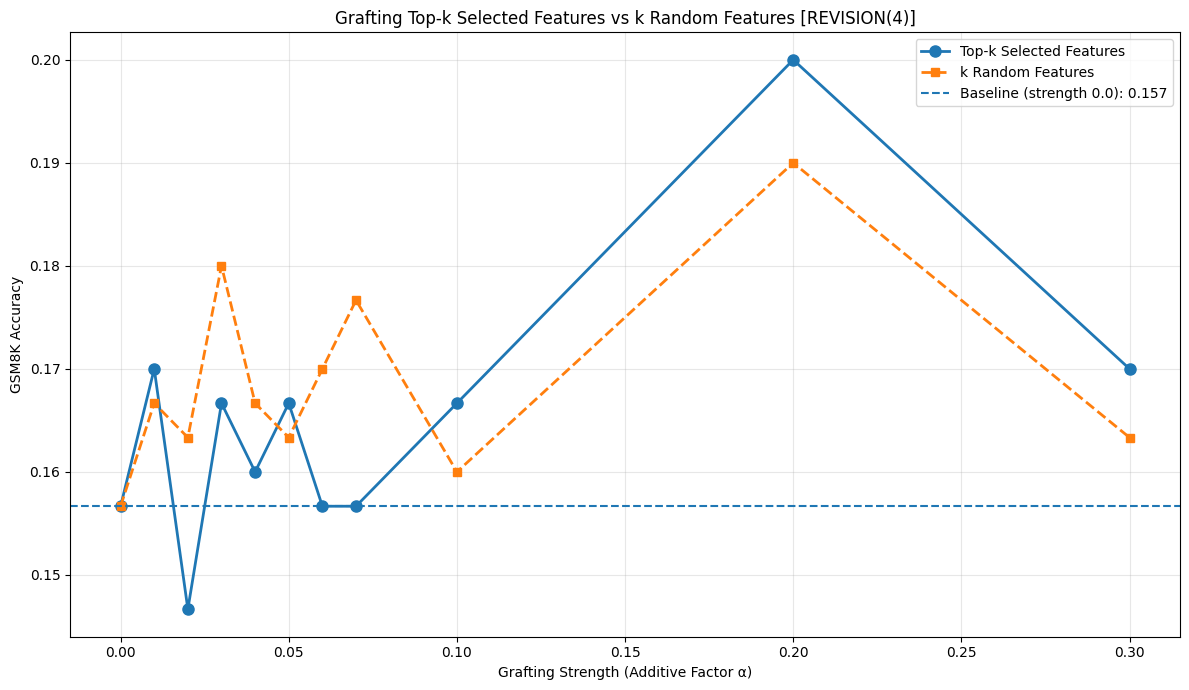


Summary (Selected vs Random)
Strength 0.00: Selected = 0.157, Random = 0.157
Strength 0.01: Selected = 0.170, Random = 0.167
Strength 0.02: Selected = 0.147, Random = 0.163
Strength 0.03: Selected = 0.167, Random = 0.180
Strength 0.04: Selected = 0.160, Random = 0.167
Strength 0.05: Selected = 0.167, Random = 0.163
Strength 0.06: Selected = 0.157, Random = 0.170
Strength 0.07: Selected = 0.157, Random = 0.177
Strength 0.10: Selected = 0.167, Random = 0.160
Strength 0.20: Selected = 0.200, Random = 0.190
Strength 0.30: Selected = 0.170, Random = 0.163


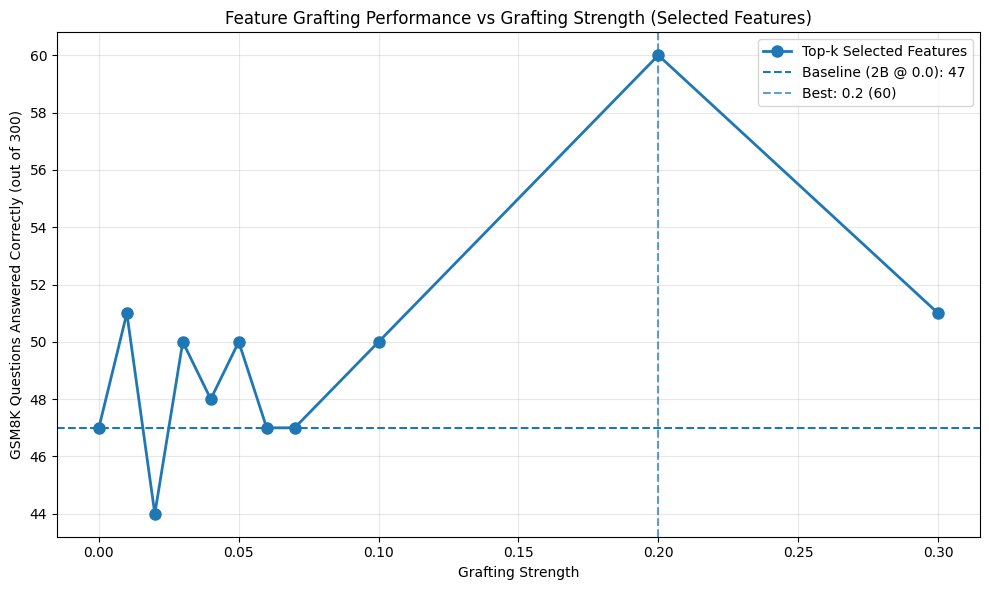


[BASELINE] Evaluating Gemma 2B base on GSM8K (no grafting)...


Baseline Gemma 2B base:   0%|          | 0/38 [00:00<?, ?it/s]

[BASELINE] Gemma 2B base: Accuracy = 0.157 (47/300)

[BASELINE] Evaluating Gemma 2B-IT (teacher) on GSM8K (no grafting)...


Baseline Gemma 2B-IT (teacher):   0%|          | 0/38 [00:00<?, ?it/s]

[BASELINE] Gemma 2B-IT (teacher): Accuracy = 0.570 (171/300)

===== BASELINE SUMMARY (NO GRAFTING) =====
Gemma 2B base accuracy:      0.157
Gemma 2B-IT (teacher) acc.:  0.570

Comparison vs selected-feature grafting runs:
Strength | Selected Acc | Δ vs plain 2B base
  0.000 |        0.157 | +0.000
  0.010 |        0.170 | +0.013
  0.020 |        0.147 | -0.010
  0.030 |        0.167 | +0.010
  0.040 |        0.160 | +0.003
  0.050 |        0.167 | +0.010
  0.060 |        0.157 | +0.000
  0.070 |        0.157 | +0.000
  0.100 |        0.167 | +0.010
  0.200 |        0.200 | +0.043
  0.300 |        0.170 | +0.013


In [7]:

print("\n" + "=" * 60)
print("Evaluating feature grafting (2B-IT → 2B base) with dynamic teacher features")
print("Selected top-k vs random-k control [REVISION(4)]")
print("=" * 60)

# --------------------
# REVISION(4): Run grafting both for selected features and random features
# --------------------
strengths_to_run_selected = [s for s in GRAFTING_STRENGTHS if s not in results_selected]

if strengths_to_run_selected:
    print("\nRunning selected-feature grafting sweeps:")
    grafting_context["reasoning_features_dict"] = reasoning_features_dict
    for strength in strengths_to_run_selected:
        acc = evaluate_gsm8k(model_a, tokenizer, evaluation_samples, strength=strength)
        results_selected[strength] = acc
        with open(CHECKPOINT_FILE, "w") as f:
            json.dump(
                {
                    "reasoning_features_dict": reasoning_features_dict,
                    "results_selected": results_selected,
                    "results_random": results_random,
                },
                f,
                indent=2,
            )
        print(f"[Selected] Completed and saved progress for strength {strength}.")
else:
    print("All selected-feature evaluation strengths already complete and loaded from checkpoint.")

# Random feature control
num_reasoning = len(reasoning_features_dict)
feature_dim = sae_b.cfg.d_sae
print(f"\nRandom feature control: sampling {num_reasoning} random features out of {feature_dim} [REVISION(4)]")

if not results_random:
    # fresh random set for first run
    random_feature_ids = np.random.choice(feature_dim, size=num_reasoning, replace=False).tolist()
    random_features_dict = {int(fid): 1.0 for fid in random_feature_ids}
else:
    # if results_random already exists, keep the same random set from checkpoint if stored
    # (for simplicity we do not store it; in a real project, you'd persist the random IDs too)
    random_feature_ids = np.random.choice(feature_dim, size=num_reasoning, replace=False).tolist()
    random_features_dict = {int(fid): 1.0 for fid in random_feature_ids}

grafting_context["reasoning_features_dict"] = random_features_dict

strengths_to_run_random = [s for s in GRAFTING_STRENGTHS if s not in results_random]

if strengths_to_run_random:
    print("\nRunning random-feature grafting sweeps:")
    for strength in strengths_to_run_random:
        acc = evaluate_gsm8k(model_a, tokenizer, evaluation_samples, strength=strength)
        results_random[strength] = acc
        with open(CHECKPOINT_FILE, "w") as f:
            json.dump(
                {
                    "reasoning_features_dict": reasoning_features_dict,
                    "results_selected": results_selected,
                    "results_random": results_random,
                },
                f,
                indent=2,
            )
        print(f"[Random] Completed and saved progress for strength {strength}.")
else:
    print("All random-feature evaluation strengths already complete and loaded from checkpoint.")

print("\n" + "=" * 60)
print("Analyzing grafting results (selected vs random) [REVISION(4)]")
print("=" * 60)

# Use baseline = strength 0.0 from selected results if present
baseline_accuracy = results_selected.get(0.0, 0.0)

strengths_sorted = sorted(GRAFTING_STRENGTHS)
acc_selected = [results_selected.get(s, np.nan) for s in strengths_sorted]
acc_random = [results_random.get(s, np.nan) for s in strengths_sorted]

plt.figure(figsize=(12, 7))
plt.plot(strengths_sorted, acc_selected, "o-", linewidth=2, markersize=8, label="Top-k Selected Features")
plt.plot(strengths_sorted, acc_random, "s--", linewidth=2, markersize=6, label="k Random Features")
plt.xlabel("Grafting Strength (Additive Factor α)")
plt.ylabel("GSM8K Accuracy")
plt.title("Grafting Top-k Selected Features vs k Random Features [REVISION(4)]")
plt.grid(True, alpha=0.3)
if baseline_accuracy > 0:
    plt.axhline(
        y=baseline_accuracy,
        linestyle="--",
        label=f"Baseline (strength 0.0): {baseline_accuracy:.3f}",
    )
plt.legend()
plt.tight_layout()
plt.savefig("gsm8k_selected_vs_random_grafting_results_2b_2bit_dynamic.png", dpi=150)
plt.show()

print("\nSummary (Selected vs Random)")
for strength in strengths_sorted:
    sel = results_selected.get(strength, float("nan"))
    rnd = results_random.get(strength, float("nan"))
    print(f"Strength {strength:3.2f}: Selected = {sel:.3f}, Random = {rnd:.3f}")

# For convenience, also plot #correct (out of N) for the selected run
new_strengths = strengths_sorted
new_accuracies = acc_selected

plt.figure(figsize=(10, 6))
plt.plot(
    np.array(new_strengths),
    np.array(new_accuracies) * len(evaluation_samples),
    "o-",
    linewidth=2,
    markersize=8,
    label="Top-k Selected Features"
)
plt.xlabel("Grafting Strength")
plt.ylabel(f"GSM8K Questions Answered Correctly (out of {len(evaluation_samples)})")
plt.title("Feature Grafting Performance vs Grafting Strength (Selected Features)")
plt.grid(True, alpha=0.3)
if not np.isnan(new_accuracies[0]):
    plt.axhline(
        y=new_accuracies[0] * len(evaluation_samples),
        linestyle="--",
        label=f"Baseline (2B @ 0.0): {new_accuracies[0] * len(evaluation_samples):.0f}",
    )

if any(not np.isnan(a) for a in new_accuracies):
    best_idx = int(np.nanargmax(new_accuracies))
    best_strength = new_strengths[best_idx]
    best_accuracy = new_accuracies[best_idx]
    plt.axvline(
        x=best_strength,
        linestyle="--",
        alpha=0.7,
        label=f"Best: {best_strength} ({best_accuracy * len(evaluation_samples):.0f})",
    )
plt.legend()
plt.tight_layout()
plt.savefig("gsm8k_feature_grafting_results_2b_2bit_dynamic_selected.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================
# BASELINE EVALUATION: 2B base vs 2B-IT (no grafting)
# ============================================

def evaluate_gsm8k_plain(model, tokenizer, samples, tag="",
                         max_new_tokens=MAX_NEW_TOKENS,
                         batch_size=EVAL_BATCH_SIZE):
    """
    Plain GSM8K evaluation with no grafting or hooks.
    Uses the same extract_numerical_answer + prompts as grafting code.
    """
    model.eval()
    correct, total = 0, 0

    print(f"\n[BASELINE] Evaluating {tag} on GSM8K (no grafting)...")

    for i in tqdm(range(0, len(samples), batch_size), desc=f"Baseline {tag}"):
        batch_samples = samples[i : i + batch_size]
        prompts = [
            f"Question: {s['question']}\nLet me solve this step by step:"
            for s in batch_samples
        ]
        correct_answers = [extract_numerical_answer(s["answer"]) for s in batch_samples]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(device)

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        responses = tokenizer.batch_decode(
            generated_ids[:, inputs["input_ids"].shape[1] :],
            skip_special_tokens=True
        )

        for j, response in enumerate(responses):
            predicted_answer = extract_numerical_answer(response)
            ca = correct_answers[j]
            is_correct = (
                predicted_answer is not None
                and ca is not None
                and abs(predicted_answer - ca) < 0.01
            )
            if is_correct:
                correct += 1
            total += 1

    accuracy = correct / total if total > 0 else 0.0
    print(f"[BASELINE] {tag}: Accuracy = {accuracy:.3f} ({correct}/{total})")
    return accuracy

# Run baselines for both models
baseline_2b_base = evaluate_gsm8k_plain(
    model_a, tokenizer, evaluation_samples, tag="Gemma 2B base"
)
baseline_2b_it = evaluate_gsm8k_plain(
    model_b, tokenizer, evaluation_samples, tag="Gemma 2B-IT (teacher)"
)

print("\n===== BASELINE SUMMARY (NO GRAFTING) =====")
print(f"Gemma 2B base accuracy:      {baseline_2b_base:.3f}")
print(f"Gemma 2B-IT (teacher) acc.:  {baseline_2b_it:.3f}")

print("\nComparison vs selected-feature grafting runs:")
print("Strength | Selected Acc | Δ vs plain 2B base")
for s in strengths_sorted:
    acc = results_selected.get(s, float("nan"))
    delta = acc - baseline_2b_base if not np.isnan(acc) else float("nan")
    print(f"{s:7.3f} | {acc:12.3f} | {delta:+.3f}")
